#  Решение задачи регрессии при помощи пакета `torch`. Метрики.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://github.com/Lightning-AI/torchmetrics
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/ecosystem/metrics.html#torchmetrics

## Задачи для совместного разбора

In [44]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import time
import torch as th
from sklearn.datasets import make_regression
from torchmetrics.aggregation import MeanMetric
from torchmetrics.regression import R2Score

Scalar = TensorType[()]
patch_typeguard()

1\. Используя реализацию из `torch.nn`, решите задачу регрессии. Для расчета градиентов воспользуйтесь возможностями по автоматическому дифференцированию `torch`. В качестве функции потерь используйте собственную реализацию MSE. Для настройки весов реализуйте пакетный градиентный спуск с использованием `torch.optim.SGD`.

In [ ]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn` решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Для создания модели опишите класс `SineModel`.

Предлагаемая архитектура нейронной сети: 
1. Полносвязный слой с 100 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).

Выведите график изменения значения функции потерь в процессе обучения. Логику расчета значения функции потерь на уровне эпохи реализуйте самостоятельно.

- [ ] Проверено на семинаре

In [9]:
import torch 

torch.manual_seed(42)
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [10]:
class SineModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_out)
        )

    def forward(self, X):
        return self.net(X)

In [11]:
model = SineModel(n_features=1, n_hidden=100, n_out=1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

batch_size = 16
n_epochs = 300

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [15]:
epoch_losses = []
saved_predictions = {}
save_epochs = [0, n_epochs // 2, n_epochs - 1]

model.eval()
with torch.no_grad():
    saved_predictions[0] = model(X).detach().clone()

for epoch in range(n_epochs):
    model.train()
    batch_losses = []

    for X_batch, y_batch in loader:
        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(epoch_loss)

    if epoch in save_epochs:
        model.eval()
        with torch.no_grad():
            saved_predictions[epoch] = model(X).detach().clone()

model.eval()
with torch.no_grad():
    saved_predictions[n_epochs] = model(X).detach().clone()

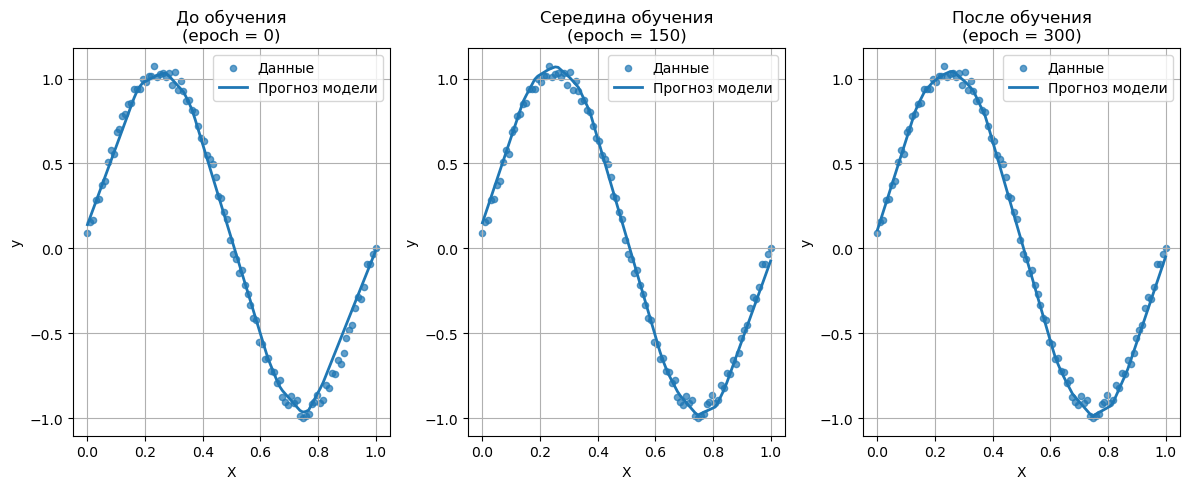

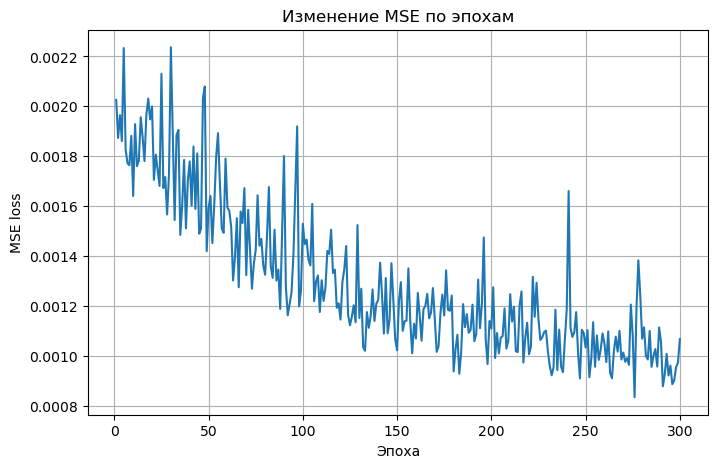

In [14]:
plt.figure(figsize=(12, 5))

plot_epochs = [0, n_epochs // 2, n_epochs]
titles = ["До обучения", "Середина обучения", "После обучения"]

for i, (ep, title) in enumerate(zip(plot_epochs, titles), 1):
    plt.subplot(1, 3, i)
    plt.scatter(X.numpy(), y.numpy(), s=20, alpha=0.7, label="Данные")
    plt.plot(X.numpy(), saved_predictions[ep].numpy(), linewidth=2, label="Прогноз модели")
    plt.title(f"{title}\n(epoch = {ep})")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), epoch_losses)
plt.title("Изменение MSE по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.grid(True)
plt.show()

<p class="task" id="2"></p>

2\. Повторите решение задачи 1, изменив модель. Для создания модели создайте объект класса `nn.Sequential`.

Предлагаемая архитектура нейронной сети: 
1. Полносвязный слой с 50 нейронами
2. Активация Tanh
3. Полносвязный слой с 1 нейроном

- [ ] Проверено на семинаре

In [23]:
import torch 

torch.manual_seed(42)
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [24]:
model = nn.Sequential(
    nn.Linear(1, 50),
    nn.Tanh(),
    nn.Linear(50, 1)
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [25]:
batch_size = 16
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [26]:
n_epochs = 300
epoch_losses = []

saved_predictions = {}
save_epochs = [0, n_epochs // 2, n_epochs - 1]

model.eval()
with torch.no_grad():
    saved_predictions[0] = model(X).detach().clone()

for epoch in range(n_epochs):

    model.train()
    batch_losses = []

    for X_batch, y_batch in loader:

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(epoch_loss)

    if epoch in save_epochs:
        model.eval()
        with torch.no_grad():
            saved_predictions[epoch] = model(X).detach().clone()

model.eval()
with torch.no_grad():
    saved_predictions[n_epochs] = model(X).detach().clone()

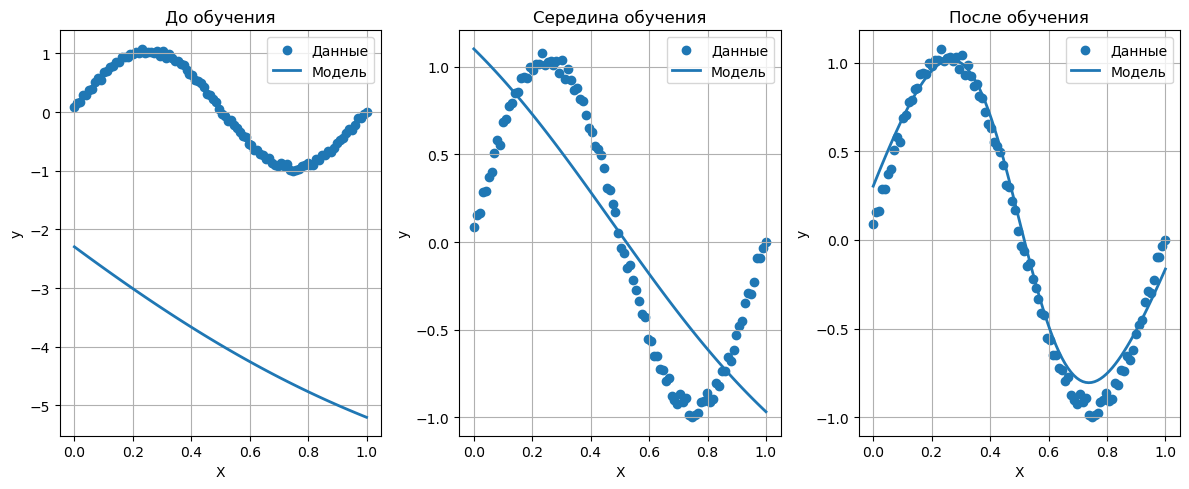

In [27]:
plt.figure(figsize=(12,5))

epochs_to_plot = [0, n_epochs//2, n_epochs]
titles = ["До обучения", "Середина обучения", "После обучения"]

for i, (ep, title) in enumerate(zip(epochs_to_plot, titles), 1):
    plt.subplot(1,3,i)
    plt.scatter(X.numpy(), y.numpy(), label="Данные")
    plt.plot(X.numpy(), saved_predictions[ep].numpy(), linewidth=2, label="Модель")
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

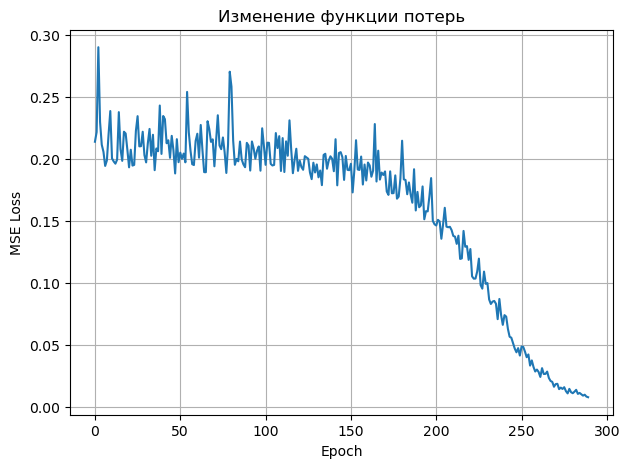

In [29]:
plt.figure(figsize=(7,5))
plt.plot(epoch_losses[10:])
plt.title("Изменение функции потерь")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid()
plt.show()

<p class="task" id="3"></p>

3\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Перенесите вычисления на GPU и сравните время обучения с и без использования GPU. Решение должно корректно работать в случае отсутствия GPU без дополнительных изменений в коде. 

- [ ] Проверено на семинаре

In [33]:
X, y, coef = make_regression(
    n_samples=10000,
    n_features=10,
    n_informative=6,
    coef=True,
    bias=0.5,
    random_state=42
)

X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)


In [34]:
class RegressionModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_out)
        )

    def forward(self, x):
        return self.net(x)

In [35]:
def train_model(device, X, y, n_epochs=100, batch_size=128, lr=0.01):
    X_device = X.to(device)
    y_device = y.to(device)

    dataset = TensorDataset(X_device, y_device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = RegressionModel(n_features=X.shape[1], n_hidden=64, n_out=1).to(device)
    criterion = nn.MSELoss()
    optimizer = th.optim.SGD(model.parameters(), lr=lr)

    epoch_losses = []

    if device.type == "cuda":
        th.cuda.synchronize()

    start_time = time.perf_counter()

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []

        for X_batch, y_batch in loader:
            optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss = sum(batch_losses) / len(batch_losses)
        epoch_losses.append(epoch_loss)

    if device.type == "cuda":
        th.cuda.synchronize()

    end_time = time.perf_counter()
    training_time = end_time - start_time

    return model, epoch_losses, training_time

In [36]:
cpu_device = th.device("cpu")
cpu_model, cpu_losses, cpu_time = train_model(cpu_device, X, y)

print(f"Время обучения на CPU: {cpu_time:.4f} сек")


if th.cuda.is_available():
    gpu_device = th.device("cuda")
    gpu_model, gpu_losses, gpu_time = train_model(gpu_device, X, y)

    print(f"Время обучения на GPU: {gpu_time:.4f} сек")
    print(f"Ускорение GPU/CPU: {cpu_time / gpu_time:.2f}x")
else:
    gpu_losses = None
    gpu_time = None
    print("GPU недоступен. Код корректно отработал на CPU без изменений.")

Время обучения на CPU: 9.7187 сек
GPU недоступен. Код корректно отработал на CPU без изменений.


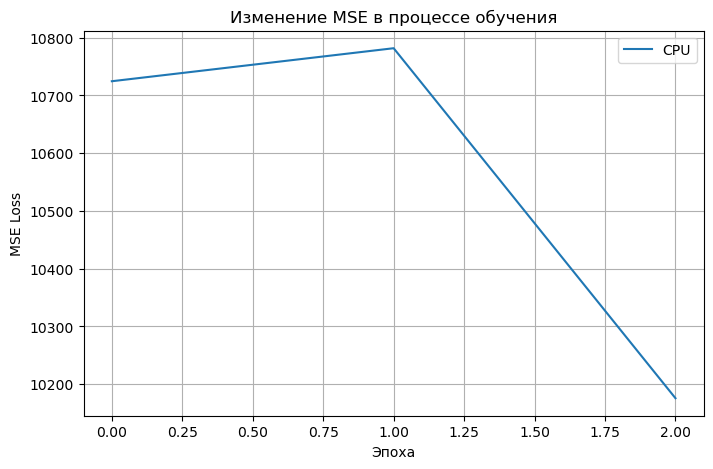

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(cpu_losses, label="CPU")

if gpu_losses is not None:
    plt.plot(gpu_losses, label="GPU")

plt.title("Изменение MSE в процессе обучения")
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="4"></p>

4\. Повторите решение задач 1-2, используя для расчета значения функции потерь за эпоху метрику `MeanMetric` из пакета `torchmetrics`. Добавьте в цикл обучения расчет метрики $R^2$ (воспользуйтесь реализацией из `torchmetrics`). Выведите на экран график изменения значения функции потерь и метрики $R^2$ по эпохам в процессе обучения.

In [38]:
torch.manual_seed(42)

X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [39]:
def build_sequential_model():
    return nn.Sequential(
        nn.Linear(1, 50),
        nn.Tanh(),
        nn.Linear(50, 1)
    )

In [40]:
def train_model(model, loader, X, y, n_epochs=300, lr=0.1):
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_history = []
    r2_history = []
    saved_predictions = {}

    save_epochs = [0, n_epochs // 2, n_epochs]

    # прогноз до обучения
    model.eval()
    with torch.no_grad():
        saved_predictions[0] = model(X).detach().clone()

    for epoch in range(1, n_epochs + 1):
        model.train()

        # метрики на эпоху
        epoch_loss_metric = MeanMetric()
        epoch_r2_metric = R2Score()

        for X_batch, y_batch in loader:
            optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            # обновляем метрики
            epoch_loss_metric.update(loss.detach())
            epoch_r2_metric.update(y_pred.detach(), y_batch)

        # считаем итоговые значения за эпоху
        epoch_loss = epoch_loss_metric.compute().item()
        epoch_r2 = epoch_r2_metric.compute().item()

        loss_history.append(epoch_loss)
        r2_history.append(epoch_r2)

        # сохраняем промежуточные прогнозы
        if epoch in save_epochs:
            model.eval()
            with torch.no_grad():
                saved_predictions[epoch] = model(X).detach().clone()

    return loss_history, r2_history, saved_predictions

In [45]:
model1 = SineModel(n_features=1, n_hidden=100, n_out=1)
loss_1, r2_1, preds_1 = train_model(model1, loader, X, y, n_epochs=300, lr=0.1)

model2 = build_sequential_model()
loss_2, r2_2, preds_2 = train_model(model2, loader, X, y, n_epochs=300, lr=0.1)

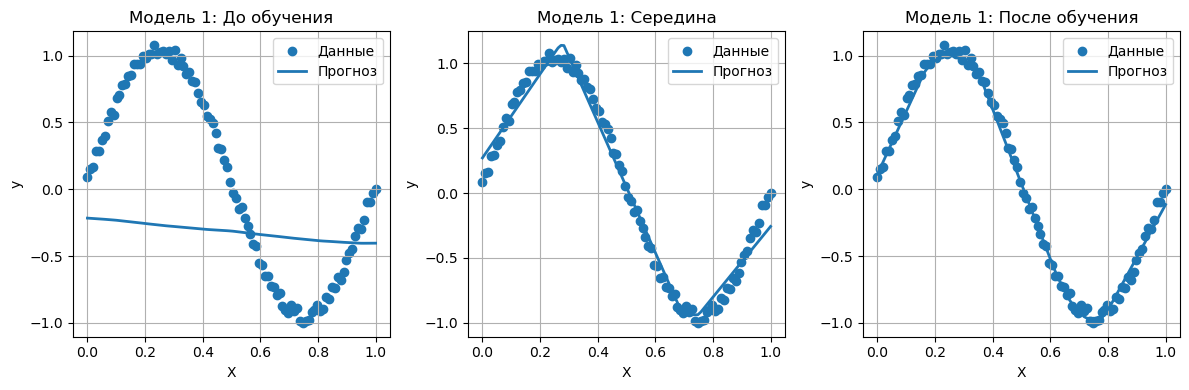

In [46]:
plt.figure(figsize=(12, 4))

epochs_to_plot = [0, 150, 300]
titles = ["До обучения", "Середина", "После обучения"]

for i, (ep, title) in enumerate(zip(epochs_to_plot, titles), 1):
    plt.subplot(1, 3, i)
    plt.scatter(X.numpy(), y.numpy(), label="Данные")
    plt.plot(X.numpy(), preds_1[ep].numpy(), linewidth=2, label="Прогноз")
    plt.title(f"Модель 1: {title}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

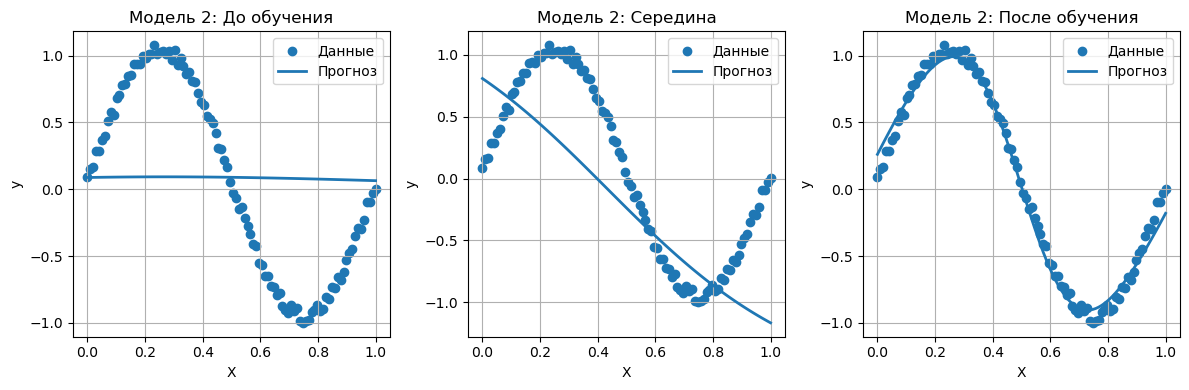

In [47]:
plt.figure(figsize=(12, 4))

for i, (ep, title) in enumerate(zip(epochs_to_plot, titles), 1):
    plt.subplot(1, 3, i)
    plt.scatter(X.numpy(), y.numpy(), label="Данные")
    plt.plot(X.numpy(), preds_2[ep].numpy(), linewidth=2, label="Прогноз")
    plt.title(f"Модель 2: {title}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

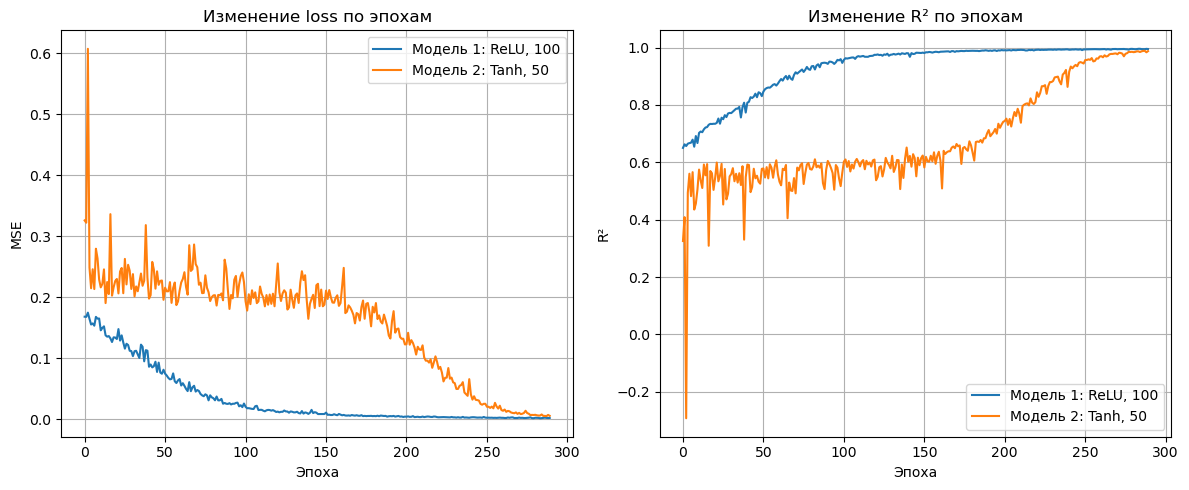

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_1[10:], label="Модель 1: ReLU, 100")
plt.plot(loss_2[10:], label="Модель 2: Tanh, 50")
plt.title("Изменение loss по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(r2_1[10:], label="Модель 1: ReLU, 100")
plt.plot(r2_2[10:], label="Модель 2: Tanh, 50")
plt.title("Изменение R² по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("R²")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение задач 1-2, изменив функцию потерь. Обучите модель, используя три функции потерь: `MSELoss`, `L1Loss` и `HuberLoss` - и выведите на одном графике динамику изменения метрики $R^2$ по эпохам для каждой модели в процессе обучения. Добавьте подписи полученных кривых.

- [ ] Проверено на семинаре

In [50]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [51]:
def train_model(model, loader, loss_fn, n_epochs=300, lr=0.1):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    r2_history = []

    for epoch in range(n_epochs):
        model.train()

        # R² на эпоху
        r2_metric = R2Score()

        for X_batch, y_batch in loader:
            optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            r2_metric.update(y_pred.detach(), y_batch)

        epoch_r2 = r2_metric.compute().item()
        r2_history.append(epoch_r2)

    return r2_history

In [52]:
loss_functions = {
    "MSELoss": nn.MSELoss(),
    "L1Loss": nn.L1Loss(),
    "HuberLoss": nn.HuberLoss()
}


In [53]:
results_model1 = {}

for loss_name, loss_fn in loss_functions.items():
    model = SineModel(n_features=1, n_hidden=100, n_out=1)
    r2_history = train_model(model, loader, loss_fn, n_epochs=300, lr=0.1)
    results_model1[loss_name] = r2_history

In [54]:
results_model2 = {}

for loss_name, loss_fn in loss_functions.items():
    model = build_sequential_model()
    r2_history = train_model(model, loader, loss_fn, n_epochs=300, lr=0.1)
    results_model2[loss_name] = r2_history

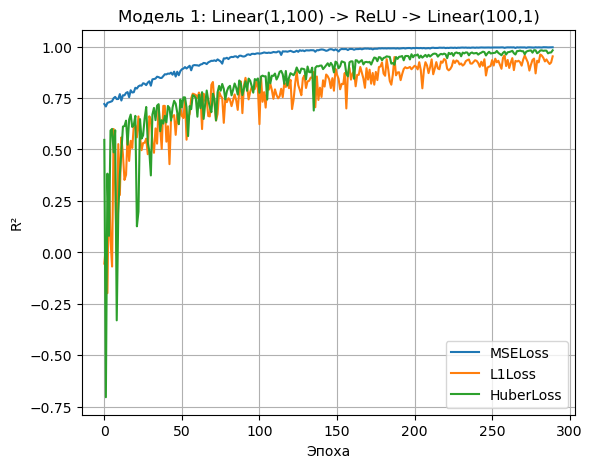

In [60]:
plt.figure(figsize=(14, 5))

# График для модели 1
plt.subplot(1, 2, 1)
for loss_name, r2_history in results_model1.items():
    plt.plot(r2_history[10:], label=loss_name)
plt.title("Модель 1: Linear(1,100) -> ReLU -> Linear(100,1)")
plt.xlabel("Эпоха")
plt.ylabel("R²")
plt.grid(True)
plt.legend()

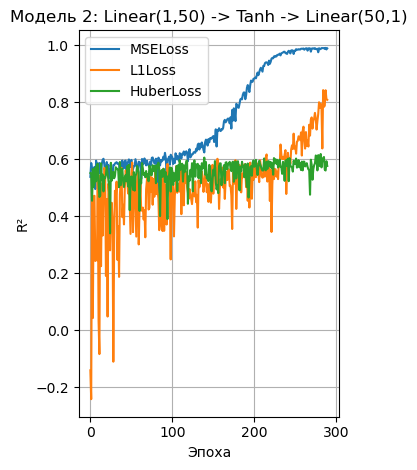

In [61]:
plt.subplot(1, 2, 2)
for loss_name, r2_history in results_model2.items():
    plt.plot(r2_history[10:], label=loss_name)
plt.title("Модель 2: Linear(1,50) -> Tanh -> Linear(50,1)")
plt.xlabel("Эпоха")
plt.ylabel("R²")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

<p class="task" id="6"></p>

6\. Повторите решение задач 1-2, разделив датасет на обучающую и тестовую выборку в соотношении 80% на 20%. Обучите модель. Для тестовой выборки посчитайте и выведите на экран значения метрик:

- MAE;
- MAPE;
- MSE;
- MSLE (MeanSquaredLogError).
 

- [ ] Проверено на семинаре

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    mean_squared_log_error
)

In [63]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

# train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

In [64]:
def train_model(model, train_loader, n_epochs=300, lr=0.1):
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        epoch_loss = sum(batch_losses) / len(batch_losses)
        loss_history.append(epoch_loss)

    return loss_history

In [65]:
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)

    y_true_np = y_test.numpy().ravel()
    y_pred_np = y_pred.numpy().ravel()

    mae = mean_absolute_error(y_true_np, y_pred_np)
    mape = mean_absolute_percentage_error(y_true_np, y_pred_np)
    mse = mean_squared_error(y_true_np, y_pred_np)

    # Для MSLE нужен сдвиг, чтобы все значения были > 0
    min_value = min(y_true_np.min(), y_pred_np.min())
    shift = 0.0
    if min_value <= 0:
        shift = abs(min_value) + 1e-6

    y_true_msle = y_true_np + shift
    y_pred_msle = y_pred_np + shift

    msle = mean_squared_log_error(y_true_msle, y_pred_msle)

    return {
        "MAE": mae,
        "MAPE": mape,
        "MSE": mse,
        "MSLE": msle
    }

In [66]:
model1 = SineModel(n_features=1, n_hidden=100, n_out=1)
loss_1 = train_model(model1, train_loader, n_epochs=300, lr=0.1)
metrics_1 = evaluate_model(model1, X_test, y_test)

print("Модель 1: Linear(1,100) -> ReLU -> Linear(100,1)")
for metric_name, metric_value in metrics_1.items():
    print(f"{metric_name}: {metric_value:.6f}")

Модель 1: Linear(1,100) -> ReLU -> Linear(100,1)
MAE: 0.040243
MAPE: 0.768855
MSE: 0.003206
MSLE: 0.000962


In [67]:
model2 = build_sequential_model()
loss_2 = train_model(model2, train_loader, n_epochs=300, lr=0.1)
metrics_2 = evaluate_model(model2, X_test, y_test)

print("Модель 2: Linear(1,50) -> Tanh -> Linear(50,1)")
for metric_name, metric_value in metrics_2.items():
    print(f"{metric_name}: {metric_value:.6f}")


Модель 2: Linear(1,50) -> Tanh -> Linear(50,1)
MAE: 0.311749
MAPE: 3.908351
MSE: 0.136962
MSLE: 0.034528


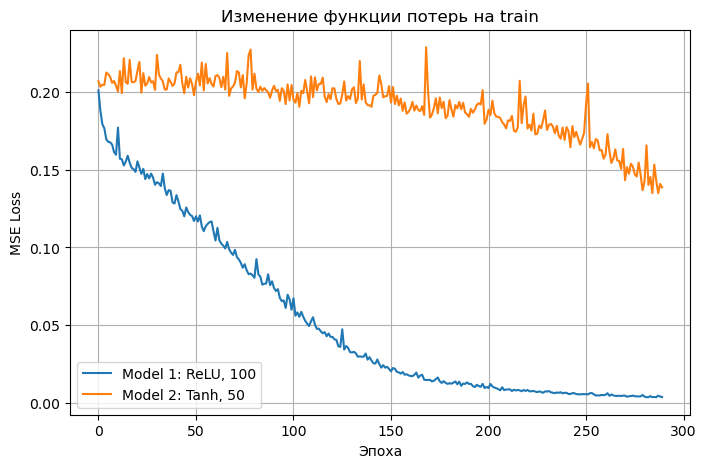

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(loss_1[10:], label="Model 1: ReLU, 100")
plt.plot(loss_2[10:], label="Model 2: Tanh, 50")
plt.title("Изменение функции потерь на train")
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()